---
date: "2026-04-09"
date-modified: last-modified
format:
  html:
    toc: true
---

# Point Set Topology

## 1. Limits of a Set and Closed Sets

**Definition:** A point $p \in M$ is a **limit of a set** $S \subset M$ if there exists a [sequence](sequences-metric-spaces.ipynb) $(p_n)$ contained entirely in $S$ that converges to $p$. 

**Definition:** A set $S$ is **closed** if it contains all of its limits.

::: {.callout-warning}
## Pugh's Non-Standard Definition of "Limit Point"

Pugh's definition of a "limit of $S$" differs from standard texts (like Rudin). 

Because Pugh allows the sequence $(p_n)$ to be a *constant* sequence ($p, p, p, \dots$), every point $p \in S$ is trivially a limit of $S$. Consequently, in Pugh's framework, a finite set *does* have limits (the points themselves). 

Most other mathematicians require a "limit point" (or accumulation point) to be the limit of a sequence of **distinct** points of $S$. Under the standard definition, a finite set has no limit points. Pugh adopts this looser definition (sometimes called "adherence" by French mathematicians) because it makes writing closure proofs much more concise.
:::

## 2. Open Sets and Topology

Let $M$ be a [metric space](metric-spaces.ipynb). The $r$-neighborhood of a point $p \in M$, denoted $M_r p$ (often called an open ball, $B_r(p)$), is the set of all points strictly within distance $r$ from $p$:

$$M_r p = \{x \in M \mid d(x, p) < r\}$$

**Definition:** $S$ is an **open** set if for each $p \in S$ there exists an $r > 0$ such that

$$d(p,q) < r \implies q \in S.$$

## 3. Duality of Open and Closed Sets

**Theorem:** Openness is dual to closedness: The complement of an open set is a closed set and the complement of a closed set is an open set.

**Proof (Suppose $S$ is open $\implies S^c$ is closed):**

Suppose that $S \subset M$ is an open set. We claim that $S^c$ is a closed set. 
By definition, we must show that if a sequence $p_n \to p$ with $p_n \in S^c$, then $p \in S^c$. 

Suppose, for the sake of contradiction, that $p \notin S^c$. Then $p \in S$. Since $S$ is open, there is an $r > 0$ such that
$$d(p, q) < r \implies q \in S$$

Since the sequence $p_n \to p$, we have $d(p, p_n) < r$ for all sufficiently large $n$. This implies that $p_n \in S$, which directly contradicts the fact that the sequence is entirely in $S^c$. 

Since the supposition that $p \in S$ leads to a contradiction, $p$ actually does lie in $S^c$. This proves that $S^c$ contains all its limits, so $S^c$ is a closed set. $\square$

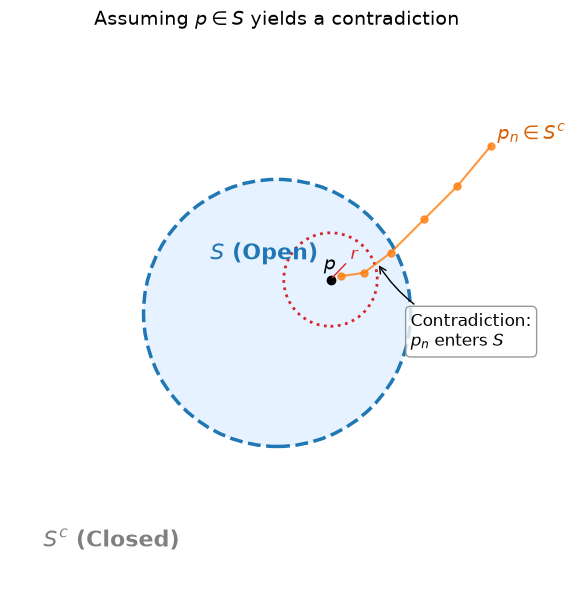

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ==========================================================
# Proof 1: S is Open => S^c is Closed
# ==========================================================
plt.style.use('default')
fig, ax1 = plt.subplots(figsize=(7, 6), facecolor='white')

# Draw Set S (Open -> dashed boundary)
S1 = patches.Circle((0, 0), 2, edgecolor='#1f77b4', facecolor='#e6f2ff', 
                    linestyle='--', linewidth=2.5, zorder=1)
ax1.add_patch(S1)

# Limit point p inside S
p1_x, p1_y = 0.8, 0.5
ax1.plot(p1_x, p1_y, 'ko', markersize=6, zorder=3)
ax1.text(p1_x - 0.1, p1_y + 0.15, '$p$', fontsize=14, zorder=3)

# Neighborhood B_r(p) strictly inside S
r = 0.7
neigh1 = patches.Circle((p1_x, p1_y), r, edgecolor='#d62728', facecolor='none', 
                        linestyle=':', linewidth=2, zorder=2)
ax1.add_patch(neigh1)
ax1.annotate('$r$', xy=(p1_x, p1_y), xytext=(p1_x + 0.3, p1_y + 0.3),
             arrowprops=dict(arrowstyle='-', color='#d62728'), color='#d62728', fontsize=12)

# Sequence p_n starting in S^c and converging to p
pn_x = np.array([3.2, 2.7, 2.2, 1.7, 1.3, 0.95])
pn_y = np.array([2.5, 1.9, 1.4, 0.9, 0.6, 0.55])
ax1.plot(pn_x, pn_y, 'o-', color='#ff7f0e', markersize=5, linewidth=1.5, alpha=0.8, zorder=3)
ax1.text(3.3, 2.6, '$p_n \\in S^c$', fontsize=14, color='#d95f02', fontweight='bold')

# Highlight the contradiction (sequence entering S)
ax1.annotate('Contradiction:\n$p_n$ enters $S$', xy=(1.5, 0.75), xytext=(2.0, -0.5),
             arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=-0.2"), 
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Labels
ax1.text(-1.0, 0.8, '$S$ (Open)', fontsize=16, color='#1f77b4', fontweight='bold')
ax1.text(-3.5, -3.5, '$S^c$ (Closed)', fontsize=16, color='gray', fontweight='bold')
ax1.set_title("Assuming $p \\in S$ yields a contradiction", fontsize=14, pad=15)
ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)
ax1.set_aspect('equal')
ax1.axis('off')

plt.tight_layout()
plt.show()

**Proof (Suppose $S$ is closed $\implies S^c$ is open):**

Suppose that $S$ is a closed set. We claim that $S^c$ is open. 
Take any $p \in S^c$. We need to show there is an $r > 0$ such that 
$$d(p, q) < r \implies q \in S^c$$

Suppose, for the sake of contradiction, that there *fails* to exist such an $r > 0$. 
Then, for each radius $r = 1/n$ (with $n = 1, 2, \dots$), there must exist at least one point $p_n$ that is within distance $1/n$ of $p$, but is *not* in $S^c$. In other words, there exists $p_n \in S$ such that $d(p, p_n) < 1/n$.

This constructs a sequence $(p_n)$ entirely in $S$ that clearly converges to $p$. Since $p \in S^c$, the limit $p$ is not in $S$. This contradicts the closedness of $S$, which requires $S$ to contain all of its limits. 

Therefore, there actually *does* exist an $r > 0$ such that $d(p, q) < r \implies q \in S^c$, which proves that $S^c$ is an open set. $\square$

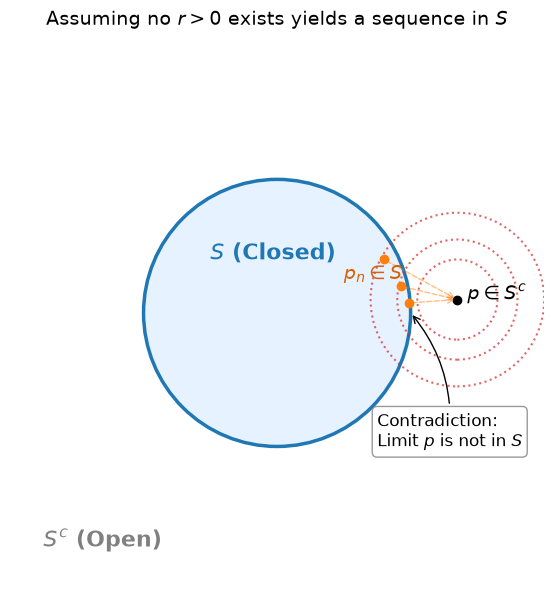

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ==========================================================
# Proof 2: S is Closed => S^c is Open
# ==========================================================
plt.style.use('default')
fig, ax2 = plt.subplots(figsize=(7, 6), facecolor='white')

# Draw Set S (Closed -> solid boundary)
S2 = patches.Circle((0, 0), 2, edgecolor='#1f77b4', facecolor='#e6f2ff', 
                    linestyle='-', linewidth=2.5, zorder=1)
ax2.add_patch(S2)

# Point p outside S (in S^c)
p2_x, p2_y = 2.7, 0.2
ax2.plot(p2_x, p2_y, 'ko', markersize=6, zorder=3)
ax2.text(p2_x + 0.15, p2_y, '$p \\in S^c$', fontsize=14, zorder=3)

# Concentric shrinking neighborhoods representing B_{1/n}(p)
radii = [1.3, 0.9, 0.6]
colors = ['#d62728', '#d62728', '#d62728']
for r, c in zip(radii, colors):
    circ = patches.Circle((p2_x, p2_y), r, edgecolor=c, facecolor='none', 
                          linestyle=':', linewidth=1.5, alpha=0.7, zorder=2)
    ax2.add_patch(circ)

# Sequence p_n constructed inside S, forced to converge to p
pn2_x = [1.6, 1.85, 1.98]
pn2_y = [0.8, 0.4, 0.15]
ax2.plot(pn2_x, pn2_y, 'o', color='#ff7f0e', markersize=6, zorder=3)

# Draw trajectory of convergence
for i in range(len(pn2_x)):
    ax2.annotate('', xy=(p2_x, p2_y), xytext=(pn2_x[i], pn2_y[i]),
                 arrowprops=dict(arrowstyle='->', color='#ff7f0e', alpha=0.5, linestyle='--'))

ax2.text(1.0, 0.5, '$p_n \\in S$', fontsize=14, color='#d95f02', fontweight='bold')

# Highlight the contradiction
ax2.annotate('Contradiction:\nLimit $p$ is not in $S$', xy=(2.0, 0.0), xytext=(1.5, -2.0),
             arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=0.2"), 
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Labels
ax2.text(-1.0, 0.8, '$S$ (Closed)', fontsize=16, color='#1f77b4', fontweight='bold')
ax2.text(-3.5, -3.5, '$S^c$ (Open)', fontsize=16, color='gray', fontweight='bold')
ax2.set_title("Assuming no $r>0$ exists yields a sequence in $S$", fontsize=14, pad=15)
ax2.set_xlim(-4, 4)
ax2.set_ylim(-4, 4)
ax2.set_aspect('equal')
ax2.axis('off')

plt.tight_layout()
plt.show()

## 4. The Axioms of Topology

The **Topology** of a metric space $M$ is the collection $\tau$ of *all open subsets* of $M$. 

**Theorem 8:** The topology $\tau$ satisfies three fundamental properties:

1. **Arbitrary Union:** The union of *any* collection of open sets is open.
2. **Finite Intersection:** The intersection of any *finite* number of open sets is open. 
3. $\emptyset, M \in \tau$.

**Proof of Arbitrary Union:**

Let $\{V_\alpha\}$ be an arbitrary collection of open sets, and let $U = \bigcup V_\alpha$. 

Let $p \in U$. By definition of union, $p \in V_\alpha$ for at least one specific index $\alpha$. 

Since $V_\alpha$ is open, there exists an $r > 0$ such that $M_r p \subset V_\alpha$. 

Because $V_\alpha \subset U$, it follows that $M_r p \subset U$. Since this holds for any $p \in U$, the union $U$ is open. $\square$

**Proof of Finite Intersection:**

Let $V_1, V_2, \dots, V_n$ be open sets, and let $U = V_1 \cap V_2 \cap \dots \cap V_n$. 

Let $p \in U$. By definition of intersection, $p$ belongs to every $V_i$. 

Since each $V_i$ is open, there exist radii $r_1, r_2, \dots, r_n > 0$ such that $M_{r_i} p \subset V_i$ for each $i$. 

Let $r = \min(r_1, r_2, \dots, r_n)$. Because the collection is *finite*, this minimum $r$ is strictly greater than $0$. 

The single neighborhood $M_r p$ is contained in every $V_i$, and therefore $M_r p \subset U$. Thus, the finite intersection $U$ is open. $\square$

**Proof that $\emptyset, M \in \tau$ (and are Clopen):**

To prove $M$ is open: Let $p \in M$. For any radius $r > 0$, the neighborhood $M_r p = \{x \in M \mid d(x, p) < r\}$ is, by definition, a set of points in $M$. Thus $M_r p \subset M$, meaning $M$ is open.

To prove $\emptyset$ is open: By definition, a set is open if *every* point inside it has a neighborhood contained in the set. Since the empty set contains no points, this condition is satisfied by [**vacuous truth**](pre-logic.ipynb). Thus, $\emptyset$ is open.

*(Furthermore, they are clopen)*: By the duality of open and closed sets, the complement of any open set is closed. 
Since $M$ is open, its complement $M^c = \emptyset$ must be closed. 
Since $\emptyset$ is open, its complement $\emptyset^c = M$ must be closed. 
Therefore, in any metric space, both $M$ and $\emptyset$ are exactly both open and closed (clopen). $\square$

### 4.1. Properties of Closed Sets

Because closed sets are the exact complements of open sets, we can use De Morgan's laws to "flip" the axioms of topology, revealing the corresponding rules for closed sets.

**Corollary:**

1. The intersection of *any* number of closed sets is a closed set.
2. The finite union of closed sets is a closed set.
3. $\emptyset$ and $M$ are closed sets.

**Proof:**
Take complements and use [De Morgan's laws](pre-logic.ipynb). 

To prove (1), let $\{K_\alpha\}$ be an arbitrary collection of closed sets. By the duality theorem, their complements $U_\alpha = (K_\alpha)^c$ are open sets. Using De Morgan's laws, we can express the intersection of the closed sets as:
$$K = \bigcap K_\alpha = \left(\bigcup U_\alpha\right)^c$$
From Theorem 8, we know the arbitrary union of open sets ($\bigcup U_\alpha$) is open. Therefore, its complement $K$ must be closed.

To prove (2), similarly, a finite union of closed sets is the complement of the finite intersection of their open complements. Since the finite intersection of open sets is open (by Theorem 8), its complement is mathematically guaranteed to be closed.

Statement (3) was already proven at the end of the previous section. $\square$


## 5. Closure, Interior, and Boundary

To analyze the anatomy of a subset $S \subset M$, we define three distinct regions:

* **Closure ($\bar{S}$):** The set of all limits of $S$. It is the *smallest closed set* containing $S$. ($S$ is closed $\iff S = \bar{S}$).
* **Interior ($\operatorname{int}(S)$ or $S^\circ$):** The union of all open sets contained in $S$. It is the *largest open set* strictly inside $S$.
* **Boundary ($\partial S$):** The set of points where every neighborhood intersects both $S$ and its complement $S^c$. Algebraically, $\partial S = \bar{S} \setminus \operatorname{int}(S)$, or equivalently $\partial S = \bar{S} \cap \overline{S^c}$. The boundary of any set is always closed.

**Theorem:** The closure of a set ($\bar{S}$) is always a closed set.

**Proof:**
By definition, a set is closed if it contains all of its limits. Therefore, we must show that any limit of $\bar{S}$ is actually contained in $\bar{S}$. (In Pugh's terms, "limits of limits are limits").

Suppose $p_n \to p$, where each $p_n \in \bar{S}$. We claim $p \in \bar{S}$.
Since each $p_n$ is a limit of $S$, there exists a sequence $(p_{n,k})_{k \in \mathbb{N}}$ entirely in $S$ that converges to $p_n$ as $k \to \infty$. 
Because this sequence converges to $p_n$, we can pick a specific term $q_n = p_{n, k(n)} \in S$ that is sufficiently close to $p_n$. Specifically, we can choose $q_n$ such that:
$$d(p_n, q_n) < \frac{1}{n}$$

Now, we examine the distance from $q_n$ to our ultimate limit point $p$. By the triangle inequality:
$$d(p, q_n) \leq d(p, p_n) + d(p_n, q_n)$$

As $n \to \infty$, we know $p_n \to p$ (so $d(p, p_n) \to 0$) and $\frac{1}{n} \to 0$ (so $d(p_n, q_n) \to 0$). Therefore:
$$d(p, q_n) \to 0$$

This implies that the sequence $(q_n)$, which lies entirely in $S$, converges to $p$. Thus, $p$ is a limit of $S$, meaning $p \in \bar{S}$. This completes the proof that $\bar{S}$ contains all its limits and is therefore a closed set. $\square$

**Visualization: The Diagonalization Technique**

This script generates a visual representation of the proof above. It shows how the sequence $p_n$ (which lies on the boundary) converges to $p$, and how the sequence $q_n$ is "diagonally" constructed from the columns of $p_{n,k}$ strictly inside the set $S$ to also converge to $p$.

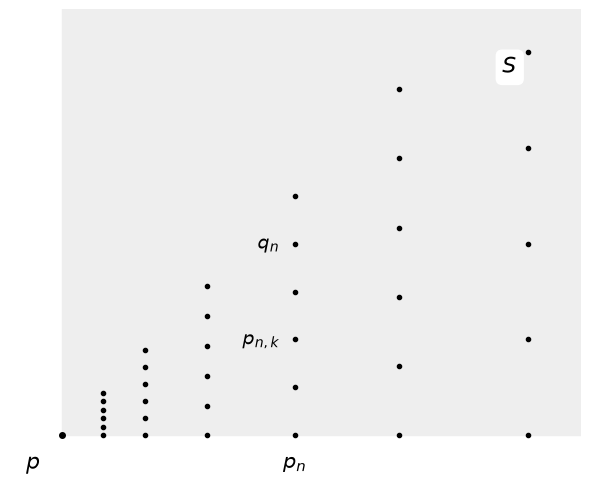

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

# Shade the set S (e.g., the open upper-right quadrant)
ax.fill_between([0, 1.1], 0, 1.1, color='#eeeeee', zorder=0)
ax.text(0.85, 0.85, '$S$', fontsize=16, 
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none"))

# Plot the ultimate limit point p
ax.plot(0, 0, 'k.', markersize=8)
ax.text(-0.04, -0.04, '$p$', fontsize=16, ha='right', va='top')

# X coordinates for the sequence p_n (converging to 0)
x_vals = [0.08, 0.16, 0.28, 0.45, 0.65, 0.9]

for i, x in enumerate(x_vals):
    # Plot p_n on the boundary (not in S)
    ax.plot(x, 0, 'k.', markersize=6)
    
    # Plot the vertical sequences p_{n,k} inside S
    y_vals = [x * (0.25 * k) for k in range(1, 6)]
    for y in y_vals:
        ax.plot(x, y, 'k.', markersize=6)
        
    # Add labels to one specific column for clarity
    if i == 3: 
        ax.text(x, -0.04, '$p_n$', fontsize=15, ha='center', va='top')
        ax.text(x - 0.03, y_vals[1], '$p_{n,k}$', fontsize=14, ha='right', va='center')
        ax.text(x - 0.03, y_vals[3], '$q_n$', fontsize=14, ha='right', va='center')

# Clean up axes for a textbook look
ax.set_xlim(-0.1, 1.0)
ax.set_ylim(-0.1, 1.0)
ax.axis('off')

plt.tight_layout()
plt.show()

**Corollary (Idempotence of Closure):** The closure of a closure is simply the closure itself ($\overline{\overline{S}} = \overline{S}$). 

**Proof:**
We know from our definitions that a set $A$ is closed if and only if it equals its own closure ($A = \bar{A}$). 
Since the preceding theorem proved that the closure $\bar{S}$ is fundamentally a closed set, we can substitute $A = \bar{S}$ directly into this equivalence. This immediately yields $\bar{S} = \overline{\overline{S}}$. $\square$

**Corollary (The Smallest Closed Set):** The closure $\bar{S}$ is the "smallest" closed set that contains $S$. Specifically, if $K$ is any closed set such that $S \subset K$, then $\bar{S} \subset K$.

**Proof:**
Suppose $K$ is a closed set that contains $S$ ($S \subset K$). 
Because $K$ is closed, it must contain the limit of every sequence in $K$ that converges. 
Since $S$ is entirely contained within $K$, every sequence in $S$ is automatically a sequence in $K$. Therefore, $K$ must contain the limits of all converging sequences in $S$. 
Since these limits are exactly what makes up the closure $\bar{S}$, it follows directly that $\bar{S} \subset K$. $\square$